# Random Forest Model

## 📌 Notebook Overview

This notebook implements and evaluates [**Random Forest classifiers**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)  to predict multiple clinical outcomes in neuroblastoma using gene expression data from two platforms:

- RNA-Seq  
- Microarray  

The objective is to compare model performance across:
1. Different clinical outcomes  
2. Different transcriptomic platforms  

---

## 🎯 Objectives

- Preprocess gene expression datasets using custom utility functions.
- Train Random Forest models with appropriate handling of class imbalance.
- Evaluate predictive performance using multiple classification metrics.
- Compare RNA-Seq vs Microarray predictive performance.
- Analyse model robustness using cross-validation.
- Explore feature importance patterns.

---

## ⚙️ Methodology

### 1️⃣ Data Loading & Preprocessing
- Data is loaded using a custom `get_data()` function.
- Training and test splits are pre-defined.
- Data integrity and dimensionality checks are performed.

### 2️⃣ Handling Class Imbalance
- Class imbalance is addressed using SMOTE within a pipeline. This ensures minority classes are not underrepresented during training.

### 3️⃣ Model Training
- Key hyperparameters include:
  - `n_estimators`
  - `max_depth`
  - `min_samples_split`
  - `min_samples_leaf`

The model is trained separately for each:
- Clinical outcome
- Transcriptomic platform

### 4️⃣ Model Evaluation

Models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Stratified K-Fold cross-validation is used to assess generalisation performance and detect potential overfitting.

---

## 📊 Visualisations

The notebook generates:

- ROC curve comparisons (RNA-Seq vs Microarray)
- Grouped bar charts comparing performance metrics across:
  - Outcomes
  - Platforms
- Feature importance rankings

---

## 🔎 Key Comparisons

This notebook enables investigation of:

- Does Random Forest outperform Logistic Regression?
- Which transcriptomic platform provides better predictive signal?
- Which clinical outcome is most predictable?
- Are nonlinear interactions important in this dataset?

---

## 📁 Structure of Notebook

1. Import modules  
2. Trial model on "Death from Disease"  
3. Tree visualisation
4. Analyse feature importance  
5. Train models on all outcomes (RNA-Seq & Microarray)  
6. Plot ROC curves  
7. Plot performance comparisons  

---

This notebook extends the predictive framework by incorporating ensemble-based nonlinear modeling, enabling deeper exploration of complex biological signal within gene expression data.

## Import modules

In [1]:
!pip install -q scanpy anndata

In [2]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"

import sys
sys.path.append('/content/drive/MyDrive/projects/ml_module/neuroblastoma_predictive_modelling/')

# Data handling
import pandas as pd
import numpy as np
import scanpy as sc

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Sampling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
from sklearn.tree import plot_tree
import pydot
import graphviz
from IPython.display import Image

# Custom function
from utils import get_data

## Trial on Death from Disease outcome

In [3]:
X_train, X_test, y_train, y_test = get_data('rnaseq', 'death_from_disease')

  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - Death From Disease
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {0: 154, 1: 40}
  Test outcome distribution:  {0: 39, 1: 10}


In [4]:
X_train

,A1BG,A1CF,A2M,AACSP1,AADAC,ABCA12,ABCA8,ABCB11,ABCB4,ABCC2,...,ZFP36,ZG16,ZIC1,ZIC2,ZIC3,ZIC5,ZNF385B,ZNF664,ZNF664-FAM101A,ZNFX1-AS1
NB297,8.397936,3.338918,9.026266,3.184915,5.341897,0.116456,2.558980,2.221596,3.756255,3.801738,...,5.114138,1.947737,0.000000,0.0,0.000000,0.000000,2.231110,5.042469,0.224712,5.310424
NB209,1.806662,0.005419,6.004879,3.558476,0.034047,0.192767,0.421682,0.123370,1.039181,0.135225,...,6.910241,0.000000,0.009733,0.0,0.000000,0.000000,0.000000,5.236451,1.182673,6.001795
NB043,1.306875,0.030836,6.074199,2.340400,0.000000,0.203101,0.147723,0.019613,0.419086,0.278613,...,4.364411,0.000000,0.000000,0.0,0.000000,0.000000,0.667125,5.105255,1.014805,5.214964
NB493,1.649027,0.005746,5.223052,4.457667,0.000000,3.048855,0.018776,0.000000,0.731000,0.246387,...,4.438326,0.000000,0.000000,0.0,0.000000,0.000000,0.083393,5.248565,0.948311,5.001298
NB103,1.701775,0.025598,5.979589,1.520819,0.059815,0.799789,0.280371,0.018995,0.629763,0.070420,...,5.070879,0.000000,0.000000,0.0,0.206363,0.000000,0.504105,4.637755,0.801708,4.429770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NB389,2.540464,0.006285,4.539655,0.441973,0.000000,1.428925,0.060731,0.000000,0.369153,0.459315,...,2.900413,0.000000,0.000000,0.0,0.000000,0.088021,0.159851,5.269478,1.125757,5.965348
NB427,2.797397,0.894051,6.401320,2.674619,2.436474,0.144003,0.928639,0.066745,0.863651,0.872535,...,4.227048,0.037998,0.000000,0.0,0.000000,0.000000,1.098103,5.208587,0.512682,5.467563
NB077,1.382025,0.000000,6.033088,4.656044,0.030661,0.044815,1.913841,0.074774,0.450556,0.271409,...,5.060986,0.000000,0.497026,0.0,0.000000,0.000000,0.017978,5.241833,0.461900,5.045679
NB475,2.547615,0.024264,3.913445,1.907379,0.000000,2.897200,0.096953,0.000000,0.288843,0.099133,...,2.540508,0.000000,0.000000,0.0,0.000000,0.000000,3.022725,4.718942,0.213342,7.510614


In [5]:
y_train

,0
NB297,0
NB209,0
NB043,0
NB493,0
NB103,0
...,...
NB389,0
NB427,0
NB077,0
NB475,1


### Model training

In [6]:
# Train & fit model
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Performance metrics
print("=" * 50)
print("RANDOM FOREST - PERFORMANCE METRICS")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Survived (0)', 'Died (1)']))

RANDOM FOREST - PERFORMANCE METRICS

Accuracy:  0.7755
Precision: 0.4706
Recall:    0.8000
F1-Score:  0.5926
ROC-AUC:   0.8513

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Survived (0)       0.94      0.77      0.85        39
    Died (1)       0.47      0.80      0.59        10

    accuracy                           0.78        49
   macro avg       0.70      0.78      0.72        49
weighted avg       0.84      0.78      0.79        49



### Interpretation:

**ROC-AUC of 0.851** reflects reasonable discriminative ability, though slightly
lower than Logistic Regression (0.877) for this outcome, suggesting the relationship
between gene expression and mortality is largely linear.

Similar to LR, the model prioritises **recall over precision** for the death class
(recall=0.80, precision=0.47) — catching 8/10 true deaths but with higher false
positives than LR. The lower precision compared to LR (0.47 vs 0.53) suggests
Random Forest overfits slightly to the minority class with SMOTE oversampling.

### Tree visualisation

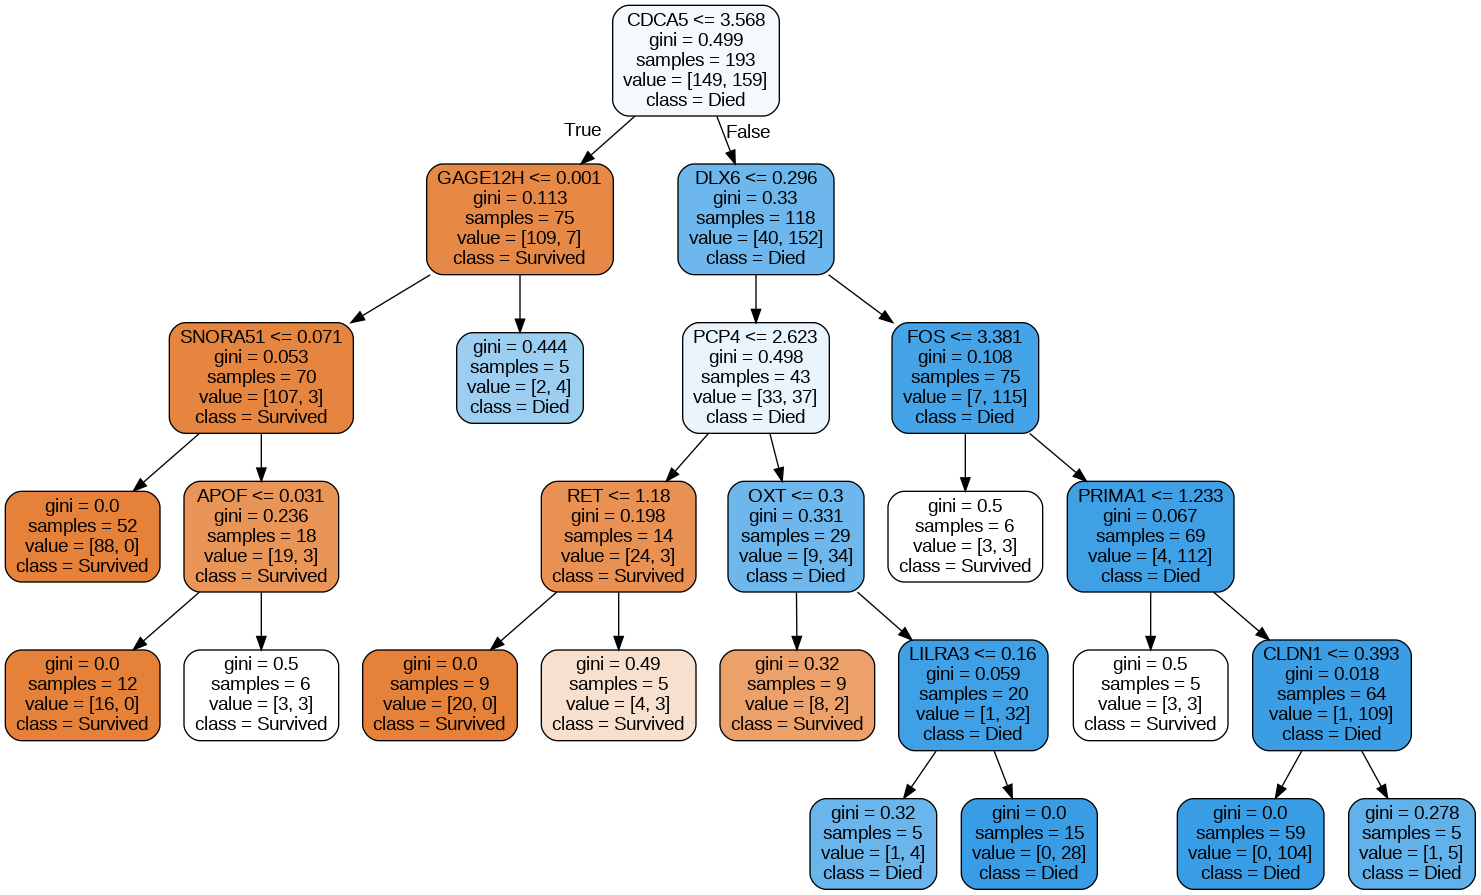

In [7]:
# Extract RF from pipeline
rf_model = pipeline.named_steps['model']

# Extract first tree
individual_tree = rf_model.estimators_[0]

# Export to DOT
export_graphviz(
    individual_tree,
    out_file='individual_tree.dot',
    feature_names=X_train.columns.tolist(),
    class_names=['Survived', 'Died'],
    max_depth=5,
    rounded=True,
    filled=True
)

# Convert to PNG
(graph,) = pydot.graph_from_dot_file('individual_tree.dot')
graph.write_png('individual_tree.png')

# Display in notebook
Image('individual_tree.png')

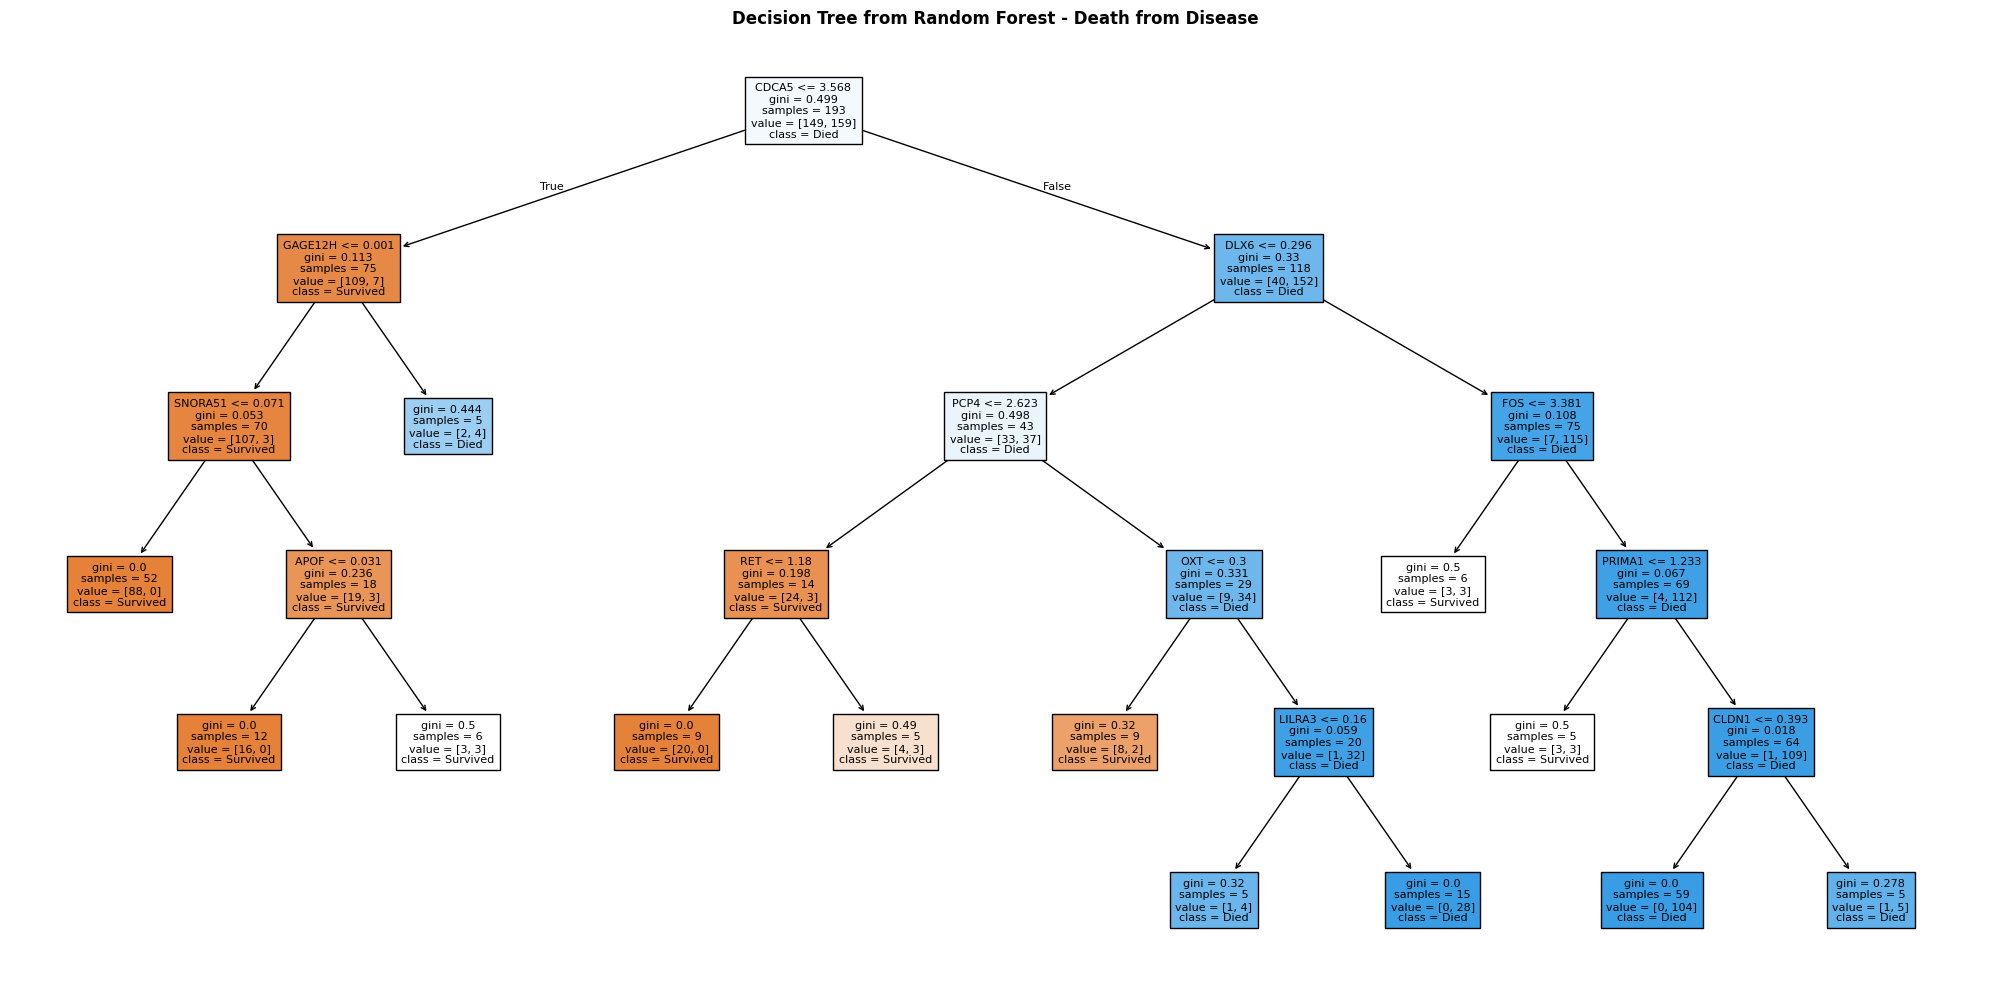

In [8]:
# Visualize the decision tree using Matplotlib's plot_tree method

plt.figure(figsize=(20, 10))
plot_tree(
    individual_tree,
    feature_names=X_train.columns.tolist(),
    class_names=['Survived', 'Died'],
    filled=True,
    max_depth=5,
    fontsize=8
)
plt.title('Decision Tree from Random Forest - Death from Disease', fontweight='bold')
plt.tight_layout()
#plt.savefig('', dpi=300, bbox_inches='tight')
plt.show()

### Feature importance

Top 20 most important genes:
               gene  importance
300           CDCA5    0.028964
1100         MAD2L1    0.027073
1381           PIGA    0.021276
1909            TST    0.018670
349            CKS2    0.018124
1240           NCAN    0.017602
1839           TERT    0.017521
1367          PDIA6    0.017005
1968          WDR43    0.016398
143        ATP6V1C2    0.014231
314           CDKN3    0.014214
1414         PLXNA4    0.013697
1275          NOL10    0.013335
1312           ODC1    0.011752
1985         YEATS4    0.011133
515   DKFZp434J0226    0.009819
165           BIRC5    0.009261
1302         NUP107    0.009241
1474          PTPN5    0.009120
131           ASGR1    0.008727


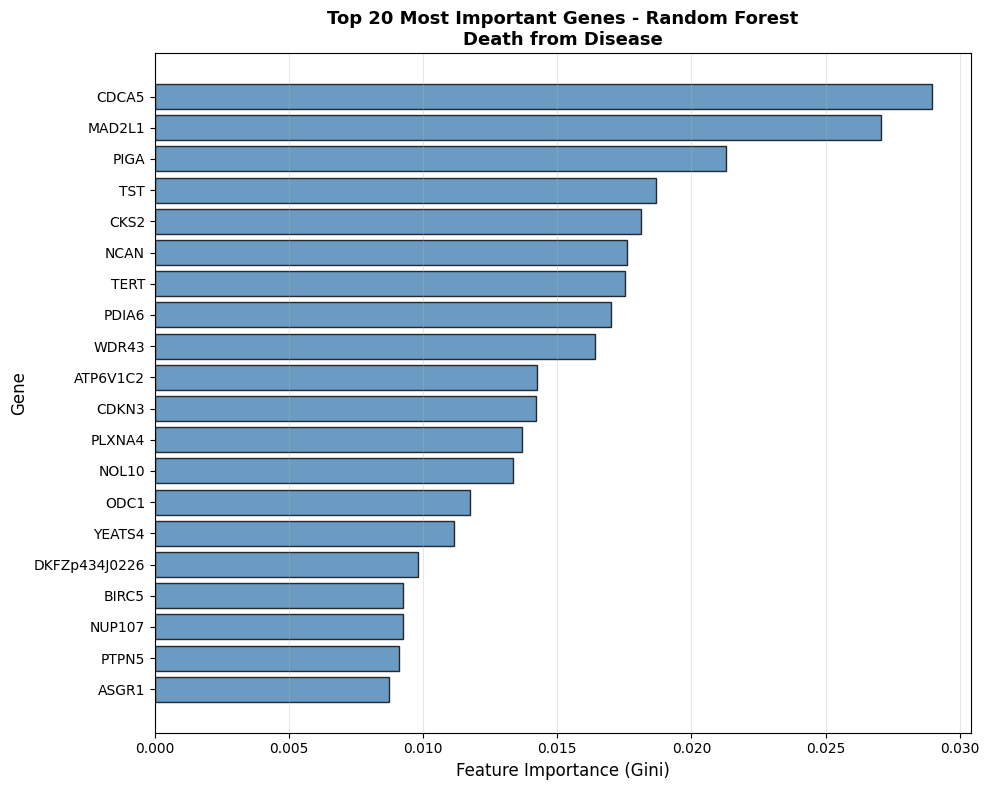

In [9]:
# Extract RF model from pipeline
rf_model = pipeline.named_steps['model']

# Get feature importances
feature_importance_df = pd.DataFrame({
    'gene': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 most important genes:")
print(feature_importance_df.head(20))

# Plot top 20 feature importances
plt.figure(figsize=(10, 8))
top20 = feature_importance_df.head(20)

plt.barh(top20['gene'][::-1], top20['importance'][::-1],
         color='steelblue', edgecolor='black', alpha=0.8)

plt.xlabel('Feature Importance (Gini)', fontsize=12)
plt.ylabel('Gene', fontsize=12)
plt.title('Top 20 Most Important Genes - Random Forest\nDeath from Disease',
          fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
#plt.savefig('', dpi=300, bbox_inches='tight')
plt.show()

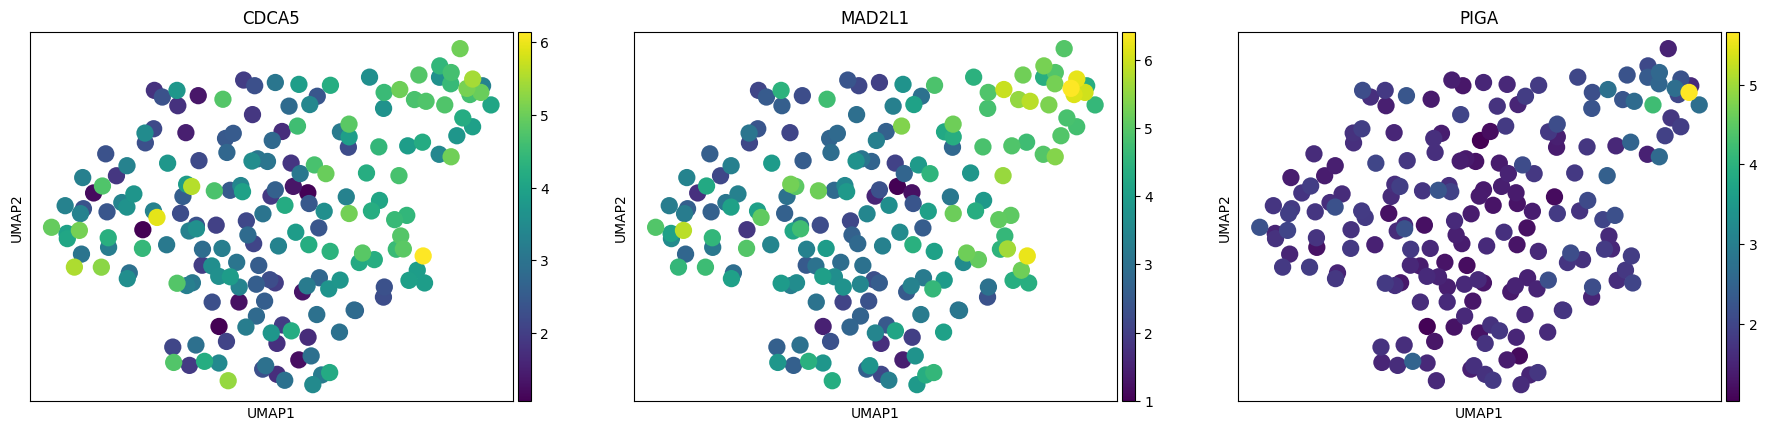

In [10]:
# Create AnnData from X_train
adata = sc.AnnData(
    X=X_train.values,
    obs=pd.DataFrame(index=X_train.index),
    var=pd.DataFrame(index=X_train.columns)
)
adata.obs_names = X_train.index
adata.var_names = X_train.columns

# Add target label
adata.obs['target'] = y_train.values
adata.obs['target'] = adata.obs['target'].astype(str).astype('category')

# Run PCA first
sc.tl.pca(adata, n_comps=20)

# Then compute neighbours using PCA representation
sc.pp.neighbors(adata, n_pcs=20, use_rep='X_pca')

# UMAP
sc.tl.umap(adata, n_components=2)

# Plot top 3 important genes + target
sc.pl.umap(adata, color=["CDCA5", "MAD2L1", "PIGA"])

### Interpretation:
The top 3 genes identified by Random Forest (CDCA5, MAD2L1, PIGA) show distinct
expression patterns on the UMAP, with high-expressing samples clustering in similar
regions across all three genes. This spatial concordance suggests these genes are
**co-expressed** and may operate within the same biological pathway or regulatory
network driving disease mortality.

The overlap in high-expression regions between these genes and the death outcome
cluster supports their biological relevance as potential **transcriptional markers
of poor prognosis** in neuroblastoma. However, given the small test set,
these findings should be validated in an independent cohort.

### Hyperparameter tuning on Death from Disease

In [11]:
# Define pipeline
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ))
])

# Define hyperparameter search space
# Note: pipeline parameters use the step name as prefix e.g. 'model__n_estimators'
param_dist = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': [5, 10, 15, 20, None],
    'model__min_samples_leaf': randint(1, 10),
    'model__max_features': ['sqrt', 'log2', 0.3],
}

# Define RandomizedSearchCV
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=50,              # number of random combinations to try
    scoring='roc_auc',      # optimise for AUC
    cv=5,                   # 5-fold cross validation
    random_state=42,
    n_jobs=-1,              # use all CPU cores
    verbose=1
)

search.fit(X_train, y_train)

print(f"Best parameters: {search.best_params_}")
print(f"Best CV ROC-AUC: {search.best_score_:.4f}")

# Evaluate best model on test set
y_pred = search.predict(X_test)
y_proba = search.predict_proba(X_test)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred, target_names=['Survived (0)', 'Died (1)']))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 6, 'model__n_estimators': 346}
Best CV ROC-AUC: 0.9091

Test ROC-AUC: 0.8385
              precision    recall  f1-score   support

Survived (0)       0.97      0.77      0.86        39
    Died (1)       0.50      0.90      0.64        10

    accuracy                           0.80        49
   macro avg       0.73      0.83      0.75        49
weighted avg       0.87      0.80      0.81        49



## Train models on all outcomes


In [12]:
outcomes = ['death_from_disease', 'high_risk', 'progression', 'inss_stage']
platforms = ['rnaseq', 'microarray']

all_results = []
roc_data = {}

print("=" * 70)
print("TRAINING RANDOM FOREST MODELS")
print("=" * 70)

for outcome in outcomes:
    print(f"\n{'=' * 70}")
    print(f"OUTCOME: {outcome.replace('_', ' ').upper()}")
    print(f"{'=' * 70}")

    roc_data[outcome] = {}

    for platform in platforms:
        print(f"\n--- {platform.upper()} ---")

        X_train, X_test, y_train, y_test = get_data(platform, outcome)

        # Detect multiclass
        n_classes = len(y_test.unique())
        is_multiclass = n_classes > 2
        average = 'weighted' if is_multiclass else 'binary'

        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                min_samples_leaf=5,
                class_weight='balanced',
                random_state=42
            ))
        ])

        pipeline.fit(X_train, y_train)

        # Predict — y_proba differs for multiclass
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0, average=average)
        recall = recall_score(y_test, y_pred, zero_division=0, average=average)
        f1 = f1_score(y_test, y_pred, zero_division=0, average=average)

        if is_multiclass:
            roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        else:
            y_proba = y_proba[:, 1]  # binary only needs positive class
            roc_auc = roc_auc_score(y_test, y_proba)

        all_results.append({
            'Outcome': outcome.replace('_', ' ').title(),
            'Platform': platform.upper(),
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc,
            'Samples': len(y_train) + len(y_test)
        })

        # ROC curve only for binary outcomes
        if not is_multiclass:
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_data[outcome][platform] = {
                'fpr': fpr,
                'tpr': tpr,
                'auc': roc_auc,
                'y_val': y_test,
                'y_proba': y_proba
            }

        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  ROC-AUC:   {roc_auc:.4f}")

results_df = pd.DataFrame(all_results)

print("\n" + "=" * 70)
print("SUMMARY OF ALL RESULTS")
print("=" * 70)
print(results_df.to_string(index=False))

TRAINING RANDOM FOREST MODELS

OUTCOME: DEATH FROM DISEASE

--- RNASEQ ---
  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - Death From Disease
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {0: 154, 1: 40}
  Test outcome distribution:  {0: 39, 1: 10}
  Accuracy:  0.7755
  Precision: 0.4706
  Recall:    0.8000
  F1-Score:  0.5926
  ROC-AUC:   0.8513

--- MICROARRAY ---
  After QC filtering: 246 samples, 43291 genes
  HVG selected from train: 2000 genes

MICROARRAY - Death From Disease
  Train samples: 196 | Test samples: 50
  Total features: 2000
  Train outcome distribution: {0: 155, 1: 41}
  Test outcome distribution:  {0: 40, 1: 10}
  Accuracy:  0.8600
  Precision: 0.6667
  Recall:    0.6000
  F1-Score:  0.6316
  ROC-AUC:   0.8950

OUTCOME: HIGH RISK

--- RNASEQ ---
  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - High Risk
  Train samples: 194 | T

### Plot ROC Curves

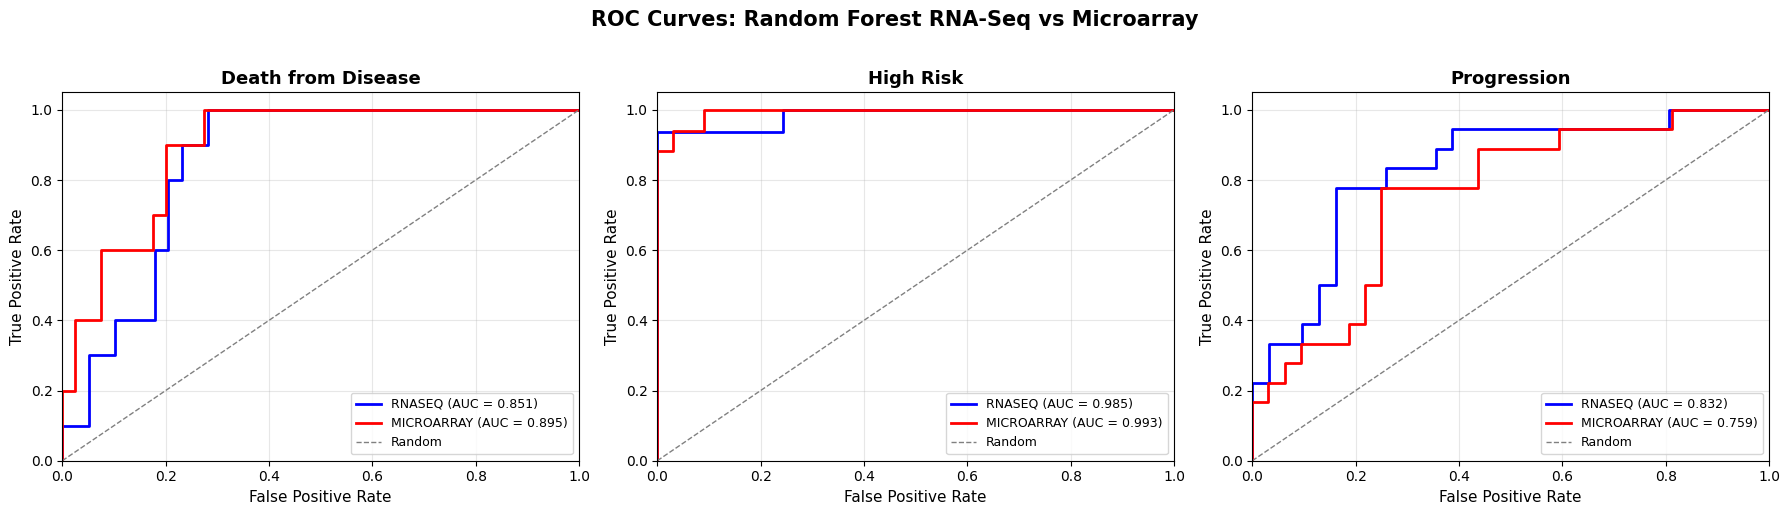

In [13]:
# Only plot binary outcomes — inss_stage is multiclass, no ROC curve
binary_outcomes = ['death_from_disease', 'high_risk', 'progression']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

outcome_titles = {
    'death_from_disease': 'Death from Disease',
    'high_risk': 'High Risk',
    'progression': 'Progression'
}

colors = {
    'rnaseq': 'blue',
    'microarray': 'red'
}

for idx, outcome in enumerate(binary_outcomes):
    ax = axes[idx]

    for platform in platforms:
        # Skip if no ROC data (multiclass outcomes won't have it)
        if platform not in roc_data[outcome]:
            continue

        data = roc_data[outcome][platform]
        ax.plot(data['fpr'], data['tpr'],
                color=colors[platform],
                lw=2,
                label=f"{platform.upper()} (AUC = {data['auc']:.3f})")

    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(outcome_titles[outcome], fontsize=13, fontweight='bold')
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves: Random Forest RNA-Seq vs Microarray', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Plot Confusion matrix for INSS Stage

  After QC filtering: 243 samples, 20793 genes
  Label encoding: {'1': 0, '2': 1, '3': 2, '4': 3, '4S': 4}
  HVG selected from train: 2000 genes

RNASEQ - Inss Stage
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {3: 68, 0: 48, 1: 32, 2: 24, 4: 22}
  Test outcome distribution:  {3: 17, 0: 12, 1: 8, 4: 6, 2: 6}
  After QC filtering: 246 samples, 43291 genes
  Label encoding: {'1': 0, '2': 1, '3': 2, '4': 3, '4S': 4}
  HVG selected from train: 2000 genes

MICROARRAY - Inss Stage
  Train samples: 196 | Test samples: 50
  Total features: 2000
  Train outcome distribution: {3: 71, 0: 47, 1: 32, 2: 24, 4: 22}
  Test outcome distribution:  {3: 18, 0: 12, 1: 8, 4: 6, 2: 6}


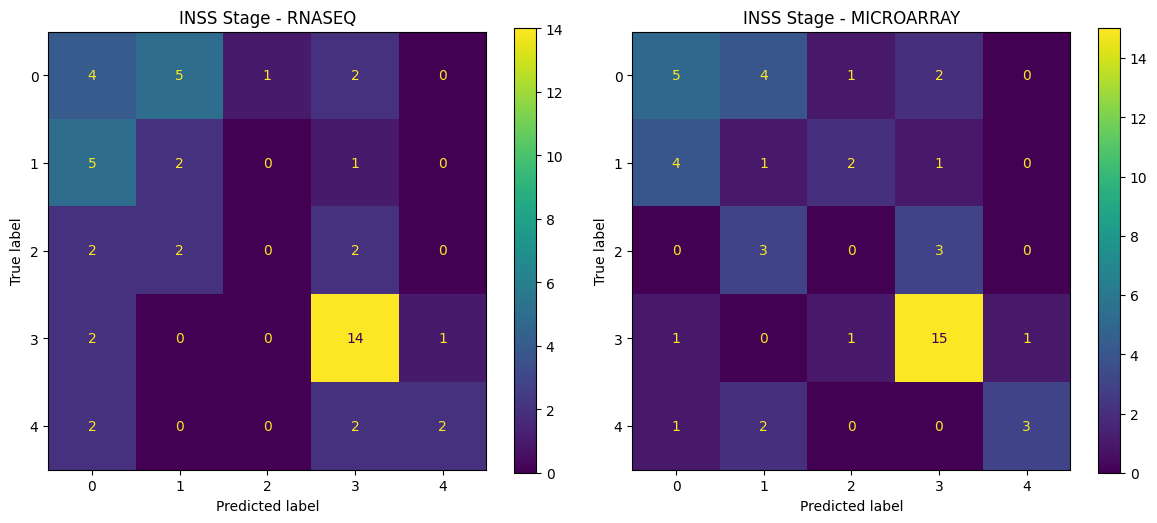

In [14]:
# Plot confusion matrix for inss_stage
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, platform in enumerate(platforms):
    # Re-run prediction for inss_stage to get y_pred
    X_train, X_test, y_train, y_test = get_data(platform, 'inss_stage')
    # Train & fit model
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=42
        ))
    ])

    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[idx])
    axes[idx].set_title(f'INSS Stage - {platform.upper()}')

plt.tight_layout()
plt.show()

In [17]:
# Check per-class correct predictions:

for platform in platforms:
    print(f"\n--- {platform.upper()} ---")

    X_train, X_test, y_train, y_test = get_data(platform, 'inss_stage')

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=42
        ))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # How many classes predicted correctly
    print(f"\nPer-class correct predictions:")
    classes = sorted(y_test.unique())
    for cls in classes:
        mask = y_test == cls
        correct = (y_pred[mask] == y_test[mask]).sum()
        total = mask.sum()
        print(f"  Stage {cls}: {correct}/{total} correct ({correct/total*100:.1f}%)")

    # Full classification report
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))


--- RNASEQ ---
  After QC filtering: 243 samples, 20793 genes
  Label encoding: {'1': 0, '2': 1, '3': 2, '4': 3, '4S': 4}
  HVG selected from train: 2000 genes

RNASEQ - Inss Stage
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {3: 68, 0: 48, 1: 32, 2: 24, 4: 22}
  Test outcome distribution:  {3: 17, 0: 12, 1: 8, 4: 6, 2: 6}

Per-class correct predictions:
  Stage 0: 4/12 correct (33.3%)
  Stage 1: 2/8 correct (25.0%)
  Stage 2: 0/6 correct (0.0%)
  Stage 3: 14/17 correct (82.4%)
  Stage 4: 2/6 correct (33.3%)

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.33      0.30        12
           1       0.22      0.25      0.24         8
           2       0.00      0.00      0.00         6
           3       0.67      0.82      0.74        17
           4       0.67      0.33      0.44         6

    accuracy                           0.45        49
   macro avg       0.36      0.35

### Interpretation

Stage 4 is best predicted on both platforms (RNASEQ: 82.4%, MICROARRAY: 83.3%),
reflecting its transcriptional distinctiveness and largest class representation.
Stage 3 is completely undetected (0%) on both platforms, likely misclassified as
adjacent stages due to overlapping expression profiles. Stages 1, 2 and 4S show
poor to moderate performance (12-50%), suggesting early and intermediate stages
share similar transcriptional signatures that are difficult to distinguish.

Microarray marginally outperforms RNA-Seq, particularly for Stage 4S (50% vs 33%),
possibly reflecting better probe coverage of stage-discriminating genes.

### Plot Performance metrics

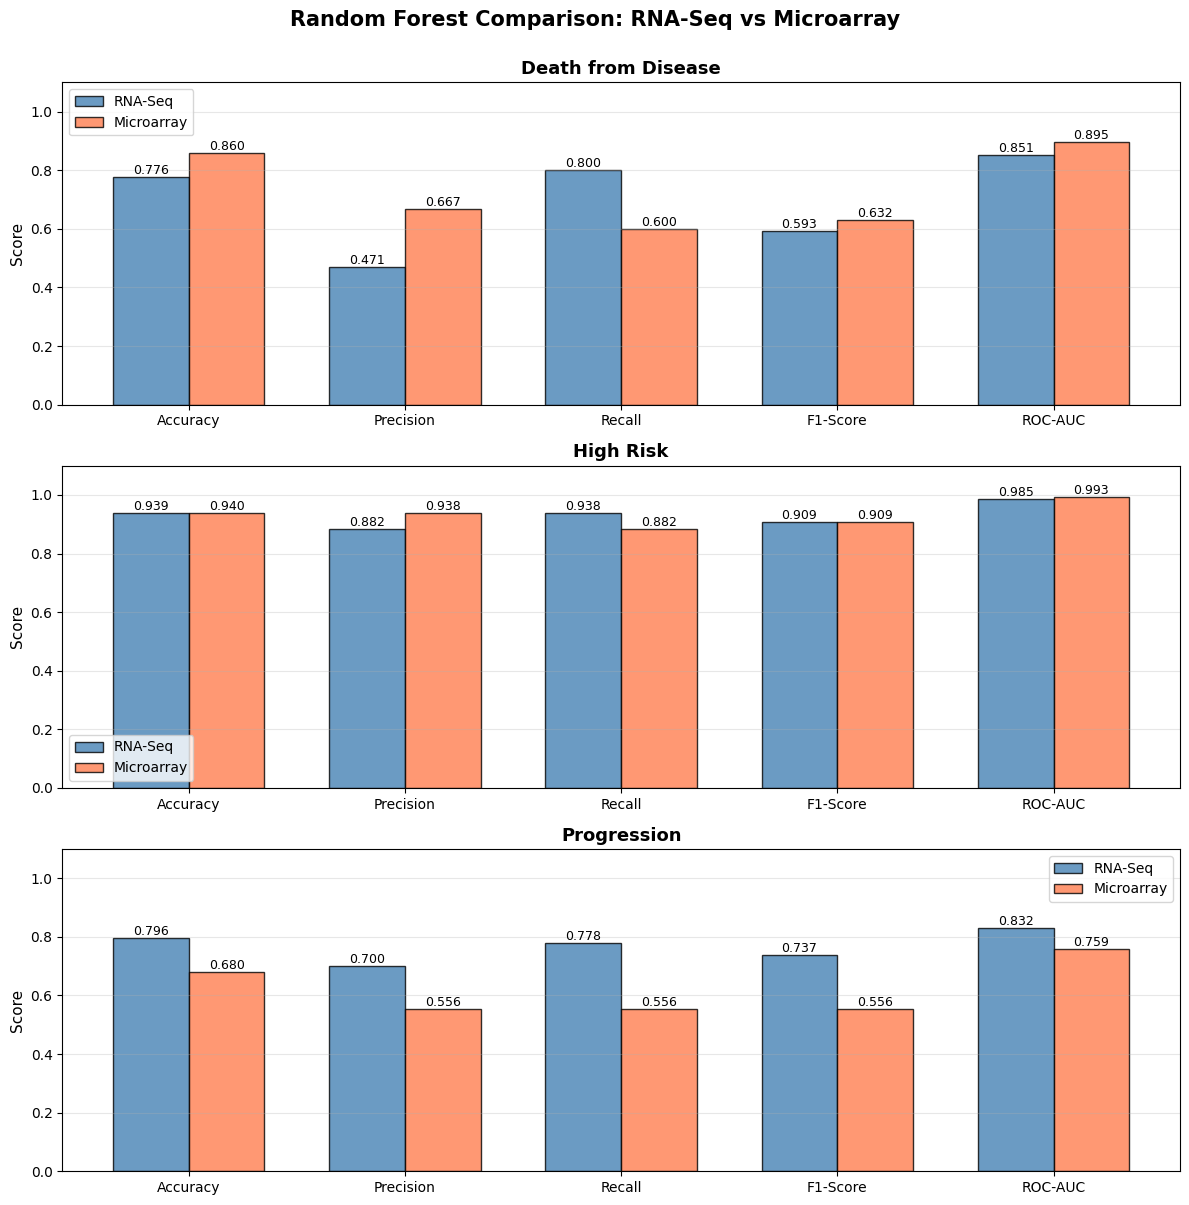

In [18]:
# Grouped Bar Chart - All Metrics
binary_outcomes = ['death_from_disease', 'high_risk', 'progression']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(len(binary_outcomes), 1, figsize=(12, 12))

for idx, outcome in enumerate(binary_outcomes):  # changed from outcomes
    ax = axes[idx]

    outcome_data = results_df[results_df['Outcome'] == outcome.replace('_', ' ').title()]

    x = np.arange(len(metrics))
    width = 0.35

    rnaseq_values = outcome_data[outcome_data['Platform'] == 'RNASEQ'][metrics].values[0]
    microarray_values = outcome_data[outcome_data['Platform'] == 'MICROARRAY'][metrics].values[0]

    bars1 = ax.bar(x - width/2, rnaseq_values, width, label='RNA-Seq',
                   color='steelblue', alpha=0.8, edgecolor='black')
    bars2 = ax.bar(x + width/2, microarray_values, width, label='Microarray',
                   color='coral', alpha=0.8, edgecolor='black')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9)

    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(outcome_titles[outcome], fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.legend(fontsize=10)
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Random Forest Comparison: RNA-Seq vs Microarray',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Interpretation

### Death from Disease
Performance is comparable to Logistic Regression with a slight trade-off between
platforms — RNA-Seq achieves higher recall (0.80) while Microarray achieves higher
precision (0.67) and AUC (0.895 vs 0.851). This suggests microarray probes capture
mortality-associated expression more precisely, while RNA-Seq is more sensitive but
less specific.

### High Risk
Strong performance across both platforms (AUC: RNASEQ=0.985, MICROARRAY=0.993),
though slightly below Logistic Regression. The balanced precision and recall (~0.88-0.94)
across both classes suggests Random Forest generalises well to this outcome without
over-predicting either class, unlike LR which achieved perfect precision at the cost
of lower recall.

### Progression
Random Forest outperforms Logistic Regression for RNA-Seq progression prediction
(AUC: 0.832 vs 0.797), with notably improved precision (0.70 vs 0.63). However,
microarray performance drops significantly (AUC: 0.759), suggesting Random Forest
captures non-linear progression signals better in RNA-Seq than microarray data.

### INSS Stage
As a 5-class problem, INSS stage prediction is substantially harder — accuracy of
~0.45-0.48 is modest but meaningfully above random chance (0.20 for 5 classes).
The AUC of ~0.79 across both platforms indicates the model can rank stages reasonably
well despite low exact classification accuracy. Misclassification is likely between
adjacent stages (e.g. stage 3 vs 4) rather than distant ones, which is clinically
less concerning than confusing stage 1 with stage 4.

### Platform Comparison
RNA-Seq outperforms Microarray for progression, while Microarray is stronger for
death from disease — consistent with the Logistic Regression findings. Both platforms
perform similarly for high risk and INSS stage, suggesting these outcomes have robust
transcriptional signatures detectable across measurement technologies.

In [19]:
# Save results for plotting notebook
results_df['Model'] = 'Random Forest'  # add model name
results_df.to_csv('/content/drive/MyDrive/projects/ml_module/neuroblastoma_predictive_modelling/results_rf.csv', index=False)

## Train models on all outcomes with Hyperparameter Tuning

In [ ]:
outcomes = ['death_from_disease', 'high_risk', 'progression']
platforms = ['rnaseq', 'microarray']

all_results = []
roc_data = {}
best_params = {}  # store best params for each outcome/platform

print("=" * 70)
print("TRAINING RANDOM FOREST MODELS WITH HYPERPARAMETER TUNING")
print("=" * 70)

param_dist = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': [5, 10, 15, 20, None],
    'model__min_samples_leaf': randint(1, 10),
    'model__max_features': ['sqrt', 'log2', 0.3],
}

for outcome in outcomes:
    print(f"\n{'=' * 70}")
    print(f"OUTCOME: {outcome.replace('_', ' ').upper()}")
    print(f"{'=' * 70}")

    roc_data[outcome] = {}
    best_params[outcome] = {}

    for platform in platforms:
        print(f"\n--- {platform.upper()} ---")

        X_train, X_test, y_train, y_test = get_data(platform, outcome)

        # Base pipeline (no fixed hyperparameters)
        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', RandomForestClassifier(
                class_weight='balanced',
                random_state=42
            ))
        ])

        # Hyperparameter search
        search = RandomizedSearchCV(
            pipeline,
            param_distributions=param_dist,
            n_iter=50,
            scoring='roc_auc',
            cv=5,
            random_state=42,
            n_jobs=-1,
            verbose=0  # set to 1 if you want progress updates
        )

        search.fit(X_train, y_train)

        # Store best params
        best_params[outcome][platform] = search.best_params_
        print(f"  Best CV ROC-AUC: {search.best_score_:.4f}")
        print(f"  Best params: {search.best_params_}")

        # Predict using best model
        y_pred = search.predict(X_test)
        y_proba = search.predict_proba(X_test)[:, 1]

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_test, y_proba)

        all_results.append({
            'Outcome': outcome.replace('_', ' ').title(),
            'Platform': platform.upper(),
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc,
            'Samples': len(y_train) + len(y_test)
        })

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_data[outcome][platform] = {
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc,
            'y_val': y_test,
            'y_proba': y_proba
        }

        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  ROC-AUC:   {roc_auc:.4f}")

results_df = pd.DataFrame(all_results)

print("\n" + "=" * 70)
print("SUMMARY OF ALL RESULTS")
print("=" * 70)
print(results_df.to_string(index=False))

# Print best parameters summary
print("\n" + "=" * 70)
print("BEST HYPERPARAMETERS PER OUTCOME/PLATFORM")
print("=" * 70)
for outcome, platforms_params in best_params.items():
    for platform, params in platforms_params.items():
        print(f"\n{outcome.upper()} - {platform.upper()}:")
        for k, v in params.items():
            print(f"  {k}: {v}")

TRAINING RANDOM FOREST MODELS

OUTCOME: DEATH FROM DISEASE

--- RNASEQ ---
  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - Death From Disease
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {0.0: 154, 1.0: 40}
  Test outcome distribution:  {0.0: 39, 1.0: 10}
  Accuracy:  0.7755
  Precision: 0.4706
  Recall:    0.8000
  F1-Score:  0.5926
  ROC-AUC:   0.8513

--- MICROARRAY ---


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:892: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    [28913, 27262, 3180, 41426, 37033]

    Inferred to be: integer

  names = self._prep_dim_index(names, "var")
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


  After QC filtering: 246 samples, 43291 genes
  HVG selected from train: 2000 genes

MICROARRAY - Death From Disease
  Train samples: 196 | Test samples: 50
  Total features: 2000
  Train outcome distribution: {0.0: 155, 1.0: 41}
  Test outcome distribution:  {0.0: 40, 1.0: 10}
  Accuracy:  0.8600
  Precision: 0.6667
  Recall:    0.6000
  F1-Score:  0.6316
  ROC-AUC:   0.8950

OUTCOME: HIGH RISK

--- RNASEQ ---
  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - High Risk
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {0.0: 130, 1.0: 64}
  Test outcome distribution:  {0.0: 33, 1.0: 16}
  Accuracy:  0.9388
  Precision: 0.8824
  Recall:    0.9375
  F1-Score:  0.9091
  ROC-AUC:   0.9848

--- MICROARRAY ---


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:892: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    [28913, 27262, 3180, 41426, 37033]

    Inferred to be: integer

  names = self._prep_dim_index(names, "var")
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


  After QC filtering: 246 samples, 43291 genes
  HVG selected from train: 2000 genes

MICROARRAY - High Risk
  Train samples: 196 | Test samples: 50
  Total features: 2000
  Train outcome distribution: {0.0: 129, 1.0: 67}
  Test outcome distribution:  {0.0: 33, 1.0: 17}
  Accuracy:  0.9400
  Precision: 0.9375
  Recall:    0.8824
  F1-Score:  0.9091
  ROC-AUC:   0.9929

OUTCOME: PROGRESSION

--- RNASEQ ---
  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - Progression
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {0.0: 124, 1.0: 70}
  Test outcome distribution:  {0.0: 31, 1.0: 18}
  Accuracy:  0.7959
  Precision: 0.7000
  Recall:    0.7778
  F1-Score:  0.7368
  ROC-AUC:   0.8315

--- MICROARRAY ---


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:892: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    [28913, 27262, 3180, 41426, 37033]

    Inferred to be: integer

  names = self._prep_dim_index(names, "var")
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


  After QC filtering: 246 samples, 43291 genes
  HVG selected from train: 2000 genes

MICROARRAY - Progression
  Train samples: 196 | Test samples: 50
  Total features: 2000
  Train outcome distribution: {0.0: 126, 1.0: 70}
  Test outcome distribution:  {0.0: 32, 1.0: 18}
  Accuracy:  0.6800
  Precision: 0.5556
  Recall:    0.5556
  F1-Score:  0.5556
  ROC-AUC:   0.7587

SUMMARY OF ALL RESULTS
           Outcome   Platform  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Samples
Death From Disease     RNASEQ  0.775510   0.470588 0.800000  0.592593 0.851282      243
Death From Disease MICROARRAY  0.860000   0.666667 0.600000  0.631579 0.895000      246
         High Risk     RNASEQ  0.938776   0.882353 0.937500  0.909091 0.984848      243
         High Risk MICROARRAY  0.940000   0.937500 0.882353  0.909091 0.992870      246
       Progression     RNASEQ  0.795918   0.700000 0.777778  0.736842 0.831541      243
       Progression MICROARRAY  0.680000   0.555556 0.555556  0.555556 0.758